In [1]:
# Cell 1: Imports

import numpy as np               # Numerical Python (arrays, math)
import random                    # Random number generation
import matplotlib.pyplot as plt  # Plotting library
from collections import deque    # Double-ended queue data structure
import sys                       # System-specific parameters/functions


In [2]:
# Cell 2: Define the Hybrid Power Flow Optimizer Class

import numpy as np
import random
from collections import deque
import sys # Assuming Cell 1 imports are available

class HybridPowerFlowOptimizer:
    """
    Optimizes power flow in an electrical grid using a hybrid metaheuristic
    approach (combining Orcas Optimization, Krill Herd, and Spotted Hyena algorithms).

    Aims to minimize generator rescheduling cost and deviation from an initial
    operating point while respecting line flow limits, generator limits, and
    maintaining power balance. Load shedding is implicitly allowed down to zero.
    """

    def __init__(self, A_matrix, line_limits, gen_costs, gen_limits_min, gen_limits_max, initial_B, memory_size=100):
        """
        Initializes the optimizer with grid parameters and the initial state.

        Args:
            A_matrix (np.ndarray): Matrix relating bus injections to line flows (e.g., PTDF matrix).
                                   Shape should be (num_lines, num_buses).
            line_limits (list or np.ndarray): Maximum absolute power flow limits for each line.
            gen_costs (list or np.ndarray): Cost coefficient ($/MW) for changing generation at each bus.
                                            Should have length num_buses (use 0 for non-generator buses).
            gen_limits_min (list or np.ndarray): Minimum generation limit (MW) for each bus.
                                                 Should have length num_buses (use 0 or -inf for non-generators).
            gen_limits_max (list or np.ndarray): Maximum generation limit (MW) for each bus.
                                                 Should have length num_buses (use 0 or +inf for non-generators).
            initial_B (np.ndarray): Initial vector of bus power injections (MW). Positive for generation,
                                    negative for load. Shape (num_buses, 1) or (num_buses,).
            memory_size (int): Maximum number of past feasible solutions to store.
        """
        print("--- Initializing HybridPowerFlowOptimizer ---")
        # --- Basic Parameter Setup ---
        self.A = A_matrix # PTDF or similar matrix
        self.line_limits = np.array(line_limits, dtype=np.float64) # Ensure float array
        self.num_buses = A_matrix.shape[1] # Number of buses inferred from A matrix columns
        self.tolerance = 1e-6 # Numerical tolerance for checks

        # Store a flattened copy of the initial bus injections
        self.initial_B = initial_B.copy().flatten()
        if self.initial_B.shape[0] != self.num_buses:
             raise ValueError(f"Initial_B length ({self.initial_B.shape[0]}) doesn't match num_buses ({self.num_buses})")

        # --- Identify Generator and Load Buses ---
        # Generators are buses with initial injection > tolerance (assuming positive generation)
        self.gen_indices = np.where(self.initial_B > self.tolerance)[0]
        # Loads are all other buses (initial injection <= tolerance)
        self.load_indices = np.where(self.initial_B <= self.tolerance)[0]

        if len(self.gen_indices) == 0:
            raise ValueError("Initialization Error: No generator buses identified based on initial_B > tolerance.")

        print(f"Identified {len(self.gen_indices)} generator buses (indices: {self.gen_indices})")
        print(f"Identified {len(self.load_indices)} load buses (indices: {self.load_indices})")

        # --- Process Generator Costs and Limits ---
        # Flatten input arrays and check dimensions
        flat_gc = np.array(gen_costs).flatten()
        flat_gmin = np.array(gen_limits_min).flatten()
        flat_gmax = np.array(gen_limits_max).flatten()
        if len(flat_gc) != self.num_buses or len(flat_gmin) != self.num_buses or len(flat_gmax) != self.num_buses:
            raise ValueError(f"Generator cost/limit array length mismatch with num_buses ({self.num_buses})")

        # Extract costs and limits only for the identified generator buses
        self.gen_costs_only = flat_gc[self.gen_indices]
        self.gen_limits_min_only = flat_gmin[self.gen_indices]
        self.gen_limits_max_only = flat_gmax[self.gen_indices]

        # --- Process Load Limits (Allowing Shedding) ---
        # Store the initial load values (which are <= tolerance, likely negative)
        self.initial_B_load_fixed = self.initial_B[self.load_indices]
        # Minimum load limit is the initial load (cannot consume more)
        self.load_limits_min_only = self.initial_B_load_fixed
        # Maximum load limit is zero (allowing shedding up to 0 MW)
        self.load_limits_max_only = np.zeros_like(self.load_limits_min_only)
        print("Load shedding enabled: Loads can be reduced down to 0 MW (Zero Cost).")


        # --- Validate and Adjust Initial State (self.initial_B) ---
        needs_adjust = False # Flag to track if adjustments were made
        print("Validating and adjusting initial state...")

        # 1. Clamp initial generator values to their limits
        initial_gen_values = self.initial_B[self.gen_indices]
        if np.any(initial_gen_values < self.gen_limits_min_only - self.tolerance) or \
           np.any(initial_gen_values > self.gen_limits_max_only + self.tolerance):
            print("Warning: Initial generator injections violate limits. Clamping...")
            self.initial_B[self.gen_indices] = np.clip(initial_gen_values,
                                                       self.gen_limits_min_only,
                                                       self.gen_limits_max_only)
            needs_adjust = True

        # 2. Check and enforce initial power balance (Total Injection ~ 0)
        # Required total injection should ideally be zero for balance
        required_total_injection = 0.0
        current_total_injection = np.sum(self.initial_B)
        difference_init = required_total_injection - current_total_injection
        num_gens = len(self.gen_indices)

        # If the initial state is significantly unbalanced...
        if abs(difference_init) > self.tolerance * self.num_buses:
            print(f"Warning: Initial injections sum to {current_total_injection:.4f} (imbalance: {difference_init:.4f}). Adjusting generators...")
            if num_gens > 0:
                # Distribute the difference evenly among generators
                diff_per_gen_init = difference_init / num_gens
                self.initial_B[self.gen_indices] += diff_per_gen_init
                # Re-clamp generator values after adjustment
                self.initial_B[self.gen_indices] = np.clip(self.initial_B[self.gen_indices],
                                                           self.gen_limits_min_only,
                                                           self.gen_limits_max_only)

                # Verify adjustment effectiveness
                final_adj_sum = np.sum(self.initial_B)
                if abs(final_adj_sum) > self.tolerance * self.num_buses * 10: # Allow slightly larger tolerance after adjustment
                     # This might happen if clamping prevents full balancing
                     print(f"ERROR: Could not fully balance initial state after adjustment. Final Sum: {final_adj_sum:.6f}")
                else:
                     print(f"Initial state balanced. New Sum: {final_adj_sum:.6f}")
                needs_adjust = True
            else:
                # Should not happen due to earlier check, but included for safety
                print("ERROR: Cannot balance initial state - no generators identified.")
                needs_adjust = True # Mark as adjusted even if failed

        if needs_adjust:
            print("-> Adjusted initial B state used for optimization:", self.initial_B)
        else:
            print("Initial state is within limits and balanced.")

        # --- Initialize Memory ---
        # Use a deque (double-ended queue) for efficient fixed-size memory
        self.memory = deque(maxlen=memory_size)
        print(f"Memory initialized with size {memory_size}.")
        print("--- Initialization Complete ---")


    def _apply_constraints(self, solution_vector):
        """
        Applies physical and operational constraints to a solution vector.

        Ensures generator/load limits are met and enforces power balance
        by adjusting generator outputs.

        Args:
            solution_vector (np.ndarray): A vector of bus power injections.

        Returns:
            np.ndarray: The constrained and balanced solution vector.
        """
        sol = solution_vector.copy().flatten() # Work with a flattened copy

        # 1. Apply Load Limits (Clip between initial load and zero)
        try:
            # Clip loads: cannot consume more than initial, can shed down to 0
            sol[self.load_indices] = np.clip(sol[self.load_indices],
                                             self.load_limits_min_only,   # Min = Initial Load (neg)
                                             self.load_limits_max_only)   # Max = 0 (shedding)
        except IndexError:
             # Handle cases where load_indices might be empty or invalid (shouldn't normally happen)
             pass # Or log a warning

        # 2. Apply Generator Limits (Clip between min and max MW)
        try:
            sol[self.gen_indices] = np.clip(sol[self.gen_indices],
                                            self.gen_limits_min_only,
                                            self.gen_limits_max_only)
        except IndexError:
             # Handle cases where gen_indices might be empty or invalid (shouldn't normally happen)
             pass # Or log a warning

        # 3. Enforce Power Balance (Sum of Gen = -Sum of Load)
        # This step adjusts generators *after* limits are applied to loads/gens individually.
        gen_values = sol[self.gen_indices]
        load_values = sol[self.load_indices]
        num_gens = len(gen_values)

        if num_gens > 0:
            required_gen = -np.sum(load_values) # Total generation needed to meet the (potentially shed) load
            current_gen = np.sum(gen_values)    # Current total generation after clipping
            difference = required_gen - current_gen # Imbalance

            # If imbalance is significant, adjust generators
            if abs(difference) > self.tolerance * max(1, num_gens): # Use scaled tolerance
                # Distribute the difference proportionally among generators
                gen_values += difference / num_gens
                # Re-clip generator values after balance adjustment
                sol[self.gen_indices] = np.clip(gen_values,
                                                self.gen_limits_min_only,
                                                self.gen_limits_max_only)

                # --- Second balance check/adjustment (optional but can help) ---
                # Check balance *again* after the adjustment and clipping
                final_gen_sum = np.sum(sol[self.gen_indices])
                final_diff = required_gen - final_gen_sum
                # If still significantly unbalanced (e.g., due to clipping saturation)
                if abs(final_diff) > self.tolerance * max(1, num_gens):
                    # Try one more proportional adjustment
                    gen_values_final = sol[self.gen_indices]
                    gen_values_final += final_diff / num_gens # Add remaining difference
                    sol[self.gen_indices] = np.clip(gen_values_final,
                                                    self.gen_limits_min_only,
                                                    self.gen_limits_max_only)
                    # Note: Perfect balance might still not be achievable if all gens hit limits

        # Return the constrained and balanced solution reshaped as a column vector
        return sol.reshape(-1, 1)


    def optimize(self, B_unused, iterations=200, population_size=30, alpha=0.7):
        """
        Runs the hybrid optimization algorithm.

        Args:
            B_unused (any): This parameter seems unused in the current logic.
                            Could be a remnant or intended for future use.
            iterations (int): Total number of optimization iterations.
            population_size (int): Number of solutions in the population for metaheuristics.
            alpha (float): This parameter seems unused in the current logic.

        Returns:
            tuple: Contains:
                - best_solution (np.ndarray): The best feasible solution found (bus injections).
                - fitness_history (list): Fitness value of the best solution at each iteration.
                - line_flows (np.ndarray): Calculated line flows for the best solution.
        """
        print(f"\n--- Starting Optimization ({iterations} iterations, {population_size} population) ---")
        # --- Initialization ---
        # Apply constraints to the (potentially adjusted) initial state
        initial_state_constrained = self._apply_constraints(self.initial_B)

        # Check memory for a previously stored feasible solution for this initial state (optional warm start)
        # Note: The current implementation doesn't seem to use B_unused to match memory keys.
        #       It just checks if *any* feasible solution is in memory.
        # cached_solution = self._check_memory(self.initial_B) # Pass initial state as key?
        # if cached_solution is not None:
        #    print("Using cached feasible solution from memory as starting point.")
        #    initial_state_constrained = cached_solution

        # Generate initial population: random solutions + constrained initial state
        initial_population = [self._generate_random_solution() for _ in range(population_size)]
        initial_population[0] = initial_state_constrained # Ensure initial state is included

        # Initialize best solution and fitness
        best_solution = initial_state_constrained.copy()
        best_fitness = self._calculate_fitness(best_solution)
        # Handle potential initial infeasibility leading to infinite fitness
        fitness_history = [best_fitness] if np.isfinite(best_fitness) else []
        if not np.isfinite(best_fitness):
             print(f"Warning: Initial constrained state has non-finite fitness ({best_fitness}). Starting search.")
             # Find the best feasible starting point from the initial population
             for sol in initial_population:
                 fit = self._calculate_fitness(sol)
                 if np.isfinite(fit) and fit < best_fitness:
                     best_fitness = fit
                     best_solution = sol.copy()
             print(f"Found initial best finite fitness: {best_fitness}")


        # Track which algorithm contributes to generating candidates
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}

        # --- Main Optimization Loop ---
        for iteration in range(iterations):
            # --- Dynamic Algorithm Selection Weights ---
            # Adjust weights based on iteration progress (example: Exploration -> Exploitation)
            if iteration < iterations * 0.3: # Early phase: Focus more on KHA?
                weights = [0.2, 0.6, 0.2] # [OOA, KHA, SHO]
            elif iteration < iterations * 0.7: # Mid phase: Balance exploration/exploitation
                weights = [0.3, 0.3, 0.4] # [OOA, KHA, SHO]
            else: # Late phase: Focus more on OOA?
                weights = [0.6, 0.2, 0.2] # [OOA, KHA, SHO]

            new_population = [] # Store solutions for the next generation

            # --- Process Each Solution in the Population ---
            for i in range(population_size):
                # Select an algorithm based on current weights
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                current_solution = initial_population[i]

                # --- Apply Selected Metaheuristic ---
                if algorithm == 'OOA': # Orcas Optimization Algorithm
                    candidate_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                elif algorithm == 'KHA': # Krill Herd Algorithm
                    candidate_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                else: # 'SHO' - Spotted Hyena Optimizer
                    candidate_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)

                algorithm_contributions[algorithm] += 1 # Track usage

                # --- Apply Constraints and Evaluate ---
                # Enforce limits and balance on the candidate generated by the metaheuristic
                new_solution = self._apply_constraints(candidate_solution)
                new_population.append(new_solution) # Add to the next generation's population

                # Calculate fitness (cost/penalty) of the constrained solution
                fitness = self._calculate_fitness(new_solution)

                # --- Update Best Solution Found So Far ---
                if np.isfinite(fitness) and fitness < best_fitness:
                    best_fitness = fitness
                    best_solution = new_solution.copy()

                    # Print progress periodically when a new best is found
                    if iteration % 50 == 0 and i == 0: # Print every 50 iters for the first agent
                        deviation = self._get_generator_deviation(best_solution)
                        cost = self._get_rescheduling_cost(best_solution)
                        print(f"Iter {iteration:>4}: New Best! Fit={best_fitness:.4e}, Dev={deviation:.2f}, GenCost={cost:.2f} ({algorithm})")

            # Update population for the next iteration
            initial_population = new_population

            # Record the best fitness for this iteration
            if np.isfinite(best_fitness):
                fitness_history.append(best_fitness)

            # Optional: Add termination condition (e.g., if fitness doesn't improve)
            # if len(fitness_history) > 50 and abs(fitness_history[-1] - fitness_history[-50]) < some_small_tolerance:
            #    print(f"Convergence suspected at iteration {iteration}. Stopping early.")
            #    break

        # --- Post-Optimization ---
        print("--- Optimization Finished ---")
        # Final constraint application to the best solution found
        best_solution = self._apply_constraints(best_solution)
        final_fitness = self._calculate_fitness(best_solution)
        print(f"Final Best Fitness: {final_fitness:.4e}")


        # Check feasibility of the final solution and store if feasible
        if self._is_feasible(best_solution, verbose=True): # Use verbose=True for detailed check output
            print("Final solution is feasible.")
            # Store the initial state and the corresponding feasible solution
            self._store_in_memory(self.initial_B, best_solution)
        else:
            print("Warning: Final solution is potentially NOT feasible according to _is_feasible check.")
            # Consider returning None or raising an error if feasibility is critical

        # Print algorithm contribution statistics
        total_calls = sum(algorithm_contributions.values())
        if total_calls > 0:
            print("\nAlgorithm Contributions:")
            for k, v in algorithm_contributions.items():
                print(f"  {k}: {v / total_calls * 100:.1f}% ({v} calls)")

        # Calculate final metrics for the best solution
        final_deviation = self._get_generator_deviation(best_solution)
        final_gen_cost = self._get_rescheduling_cost(best_solution)
        print(f"\nFinal Sum of Absolute Changes (Generators Only): {final_deviation:.4f}")
        print(f"Final Generator Rescheduling Cost: {final_gen_cost:.2f} $/hr")

        # Calculate final line flows
        final_line_flows = np.dot(self.A, best_solution.flatten()).reshape(-1, 1)

        return best_solution, fitness_history, final_line_flows


    def _get_generator_deviation(self, solution):
        """
        Calculates the sum of absolute deviations of generator outputs
        from their initial values. Used as part of the fitness function.

        Args:
            solution (np.ndarray): A solution vector (bus injections).

        Returns:
            float: Sum of absolute differences |P_gen_final - P_gen_initial|.
                   Returns np.inf if dimensions mismatch.
        """
        sol_flat = solution.flatten()
        # Ensure solution vector has expected length before indexing
        if len(sol_flat) != self.num_buses:
            return np.inf # Avoid index errors if solution is malformed

        # Get generator values from the solution
        current_gen_values = sol_flat[self.gen_indices]
        initial_gen_values = self.initial_B[self.gen_indices]

        # Double-check dimensions before calculation
        if len(current_gen_values) != len(self.gen_indices) or len(initial_gen_values) != len(self.gen_indices):
             # This check might be redundant if gen_indices is always valid, but safe
             return np.inf

        # Calculate sum of absolute differences
        return np.sum(np.abs(current_gen_values - initial_gen_values))


    def _get_rescheduling_cost(self, solution):
        """
        Calculates the total cost associated with changing generator outputs
        from their initial values, based on per-unit costs.

        Args:
            solution (np.ndarray): A solution vector (bus injections).

        Returns:
            float: Total rescheduling cost sum(cost_i * |P_gen_final_i - P_gen_initial_i|).
                   Returns np.inf if dimensions mismatch.
        """
        sol_flat = solution.flatten()
        # Ensure solution vector has expected length
        if len(sol_flat) != self.num_buses:
            return np.inf

        # Get generator values from the solution
        current_gen_values = sol_flat[self.gen_indices]
        initial_gen_values = self.initial_B[self.gen_indices]

        # Check dimensions before calculation
        if len(current_gen_values) != len(self.gen_indices) or \
           len(initial_gen_values) != len(self.gen_indices) or \
           len(self.gen_costs_only) != len(self.gen_indices):
            return np.inf # Ensure cost vector aligns

        # Calculate cost: cost_per_mw * absolute_change_mw
        cost = np.sum(self.gen_costs_only * np.abs(current_gen_values - initial_gen_values))
        return cost


    def _calculate_fitness(self, solution):
        """
        Calculates the fitness value (objective function) for a given solution.

        Lower fitness is better. Includes penalties for constraint violations
        (lines, generator limits, load limits) and objective terms related to
        generator deviation and rescheduling cost.

        Args:
            solution (np.ndarray): A solution vector (bus injections).

        Returns:
            float: The calculated fitness value (potentially np.inf for infeasible/invalid solutions).
        """
        sol_flat = solution.flatten()

        # --- Basic Validity Checks ---
        # Check for NaN or Inf values in the solution itself
        if not np.all(np.isfinite(sol_flat)):
            return np.inf # Invalid solution

        # --- Calculate Line Flows ---
        try:
            # C = A * B (Line Flows = PTDF * Bus Injections)
            line_flows = np.dot(self.A, sol_flat).flatten()
        except ValueError:
            # Handle potential dimension mismatch between A and solution
            return np.inf # Invalid calculation

        # Check for NaN or Inf values in calculated flows
        if not np.all(np.isfinite(line_flows)):
            return np.inf # Invalid flows

        # --- Penalty Calculations ---
        penalty_multiplier = 1e10 # Large constant to heavily penalize violations

        # 1. Line Limit Violation Penalty
        # Calculate violation amount: max(0, |flow| - limit - tolerance)
        line_violations = np.maximum(0, np.abs(line_flows) - (self.line_limits + self.tolerance))
        # Penalty = multiplier * sum_of_squared_violations
        line_violation_penalty = penalty_multiplier * np.sum(line_violations**2)

        # 2. Generator Limit Violation Penalty
        gen_values = sol_flat[self.gen_indices]
        gen_limit_penalty = np.inf # Default to infinite penalty
        # Check only if dimensions match correctly
        if len(gen_values) == len(self.gen_limits_min_only):
            # Calculate violations below min and above max limits
            violations_lower_gen = np.maximum(0, self.gen_limits_min_only - gen_values - self.tolerance)
            violations_upper_gen = np.maximum(0, gen_values - self.gen_limits_max_only - self.tolerance)
            # Penalty = multiplier * sum_of_squared_violations (both lower and upper)
            gen_limit_penalty = penalty_multiplier * (np.sum(violations_lower_gen**2) + np.sum(violations_upper_gen**2))

        # 3. Load Limit Violation Penalty
        load_values = sol_flat[self.load_indices]
        load_limit_penalty = np.inf # Default to infinite penalty
        # Check only if dimensions match correctly
        if len(load_values) == len(self.load_limits_min_only):
             # Calculate violations below min (initial load) and above max (zero)
             violations_lower_load = np.maximum(0, self.load_limits_min_only - load_values - self.tolerance)
             violations_upper_load = np.maximum(0, load_values - self.load_limits_max_only - self.tolerance)
             # Penalty = multiplier * sum_of_squared_violations
             load_limit_penalty = penalty_multiplier * (np.sum(violations_lower_load**2) + np.sum(violations_upper_load**2))

        # --- Objective Function Components ---
        # 1. Generator Deviation Component (penalize changes from initial state)
        generator_deviation = self._get_generator_deviation(solution)
        # Apply a weight to this deviation term
        deviation_penalty_component = 1e5 * generator_deviation # Weighting factor for deviation

        # 2. Generator Rescheduling Cost Component (actual $/hr cost)
        gen_rescheduling_cost = self._get_rescheduling_cost(solution)
        # Apply a weight to this cost term
        gen_cost_weight = 0.1 # Weighting factor for rescheduling cost

        # --- Total Fitness Calculation ---
        fitness = (line_violation_penalty       # Penalize line violations heavily
                   + gen_limit_penalty          # Penalize gen limit violations heavily
                   + load_limit_penalty         # Penalize load limit violations heavily
                   + deviation_penalty_component # Objective: Minimize deviation (weighted)
                   + gen_cost_weight * gen_rescheduling_cost # Objective: Minimize cost (weighted)
                  )

        # Return final fitness, ensuring it's finite
        return fitness if np.isfinite(fitness) else np.inf


    def _is_feasible(self, solution, verbose=False):
        """
        Checks if a given solution strictly satisfies all hard constraints.

        Args:
            solution (np.ndarray): A solution vector (bus injections).
            verbose (bool): If True, prints detailed reasons for infeasibility.

        Returns:
            bool: True if the solution is feasible, False otherwise.
        """
        if solution is None:
            if verbose: print("DEBUG (_is_feasible): Input solution is None.")
            return False

        sol_flat = solution.flatten()

        # Basic check for NaN/Inf
        if not np.all(np.isfinite(sol_flat)):
            if verbose: print("DEBUG (_is_feasible): Solution contains non-finite values.")
            return False
        if len(sol_flat) != self.num_buses:
             if verbose: print(f"DEBUG (_is_feasible): Solution length mismatch ({len(sol_flat)} vs {self.num_buses}).")
             return False

        # --- Check Constraints ---
        line_ok = False
        gen_ok = False
        load_ok = False
        bal_ok = False

        # 1. Line Limits Check
        try:
            flows = np.dot(self.A, sol_flat).flatten()
            if not np.all(np.isfinite(flows)):
                raise ValueError("Flows contain NaN/Inf")
            # Check if absolute flows are within limits (plus tolerance)
            line_ok = np.all(np.abs(flows) <= self.line_limits + self.tolerance)
        except Exception as e:
            line_ok = False # Failed calculation or check
            if verbose: print(f"DEBUG (_is_feasible): Line check error: {e}")

        # 2. Generator Limits Check
        gen_values = sol_flat[self.gen_indices]
        if len(gen_values) == len(self.gen_limits_min_only): # Check dimensions first
            gen_ok = np.all(gen_values >= self.gen_limits_min_only - self.tolerance) and \
                     np.all(gen_values <= self.gen_limits_max_only + self.tolerance)

        # 3. Load Limits Check
        load_values = sol_flat[self.load_indices]
        if len(load_values) == len(self.load_limits_min_only): # Check dimensions first
             # Check if load is between initial value (min) and 0 (max)
             load_ok = np.all(load_values >= self.load_limits_min_only - self.tolerance) and \
                       np.all(load_values <= self.load_limits_max_only + self.tolerance)

        # 4. Power Balance Check
        # Sum of all injections should be close to zero
        total_injection_sum = np.sum(sol_flat)
        bal_ok = abs(total_injection_sum) < self.tolerance * self.num_buses # Use scaled tolerance

        # --- Combine Checks and Report ---
        feasible = line_ok and gen_ok and load_ok and bal_ok

        if verbose or not feasible: # Print details if requested or if infeasible
            print(f"\n--- Feasibility Check {'PASSED' if feasible else 'FAILED'} ---")
            # Line Details
            if not line_ok:
                try:
                    flows_debug = np.dot(self.A, sol_flat).flatten()
                    failing_lines = np.where(np.abs(flows_debug) > self.line_limits + self.tolerance)[0]
                    print(f"  Line constraints FAILED. Failing line indices: {failing_lines}")
                    for idx in failing_lines[:5]: # Print details for first 5 failing lines
                         print(f"    Line {idx}: Flow={abs(flows_debug[idx]):.4f}, Limit={self.line_limits[idx]:.4f}")
                except Exception as e:
                    print(f"  Line constraints FAILED (Error during check: {e})")
            else:
                print("  Line constraints met.")

            # Generator Details
            if not gen_ok:
                if len(gen_values) == len(self.gen_limits_min_only):
                    failing_min_g = np.where(gen_values < self.gen_limits_min_only - self.tolerance)[0]
                    failing_max_g = np.where(gen_values > self.gen_limits_max_only + self.tolerance)[0]
                    print(f"  Generator limits FAILED.")
                    if len(failing_min_g) > 0:
                         idx = failing_min_g[0]
                         print(f"    Gen Bus {self.gen_indices[idx]} violated MIN Limit ({gen_values[idx]:.3f} < {self.gen_limits_min_only[idx]:.3f})")
                    if len(failing_max_g) > 0:
                         idx = failing_max_g[0]
                         print(f"    Gen Bus {self.gen_indices[idx]} violated MAX Limit ({gen_values[idx]:.3f} > {self.gen_limits_max_only[idx]:.3f})")
                else:
                     print("  Generator limits FAILED (Dimension mismatch).")
            else:
                print("  Generator limits met.")

            # Load Details
            if not load_ok:
                if len(load_values) == len(self.load_limits_min_only):
                    failing_min_l = np.where(load_values < self.load_limits_min_only - self.tolerance)[0]
                    failing_max_l = np.where(load_values > self.load_limits_max_only + self.tolerance)[0]
                    print(f"  Load limits FAILED.")
                    if len(failing_min_l) > 0:
                         idx = failing_min_l[0]
                         print(f"    Load Bus {self.load_indices[idx]} violated MIN Limit ({load_values[idx]:.3f} < {self.load_limits_min_only[idx]:.3f})")
                    if len(failing_max_l) > 0:
                         idx = failing_max_l[0]
                         print(f"    Load Bus {self.load_indices[idx]} violated MAX Limit ({load_values[idx]:.3f} > {self.load_limits_max_only[idx]:.3f})")
                else:
                     print("  Load limits FAILED (Dimension mismatch).")
            else:
                print("  Load limits met.")

            # Balance Details
            if not bal_ok:
                print(f"  Power balance FAILED. Sum of injections = {total_injection_sum:.6f}")
            else:
                print("  Power balance met.")
            print("------------------------------------------")

        return feasible


    def _generate_random_solution(self):
        """
        Generates a randomized solution vector, typically for population initialization.

        Starts from the initial state and adds perturbations to generators and loads,
        then applies constraints.

        Returns:
            np.ndarray: A randomly generated, constrained solution vector.
        """
        rand_sol = self.initial_B.copy() # Start from the initial state
        n_gens = len(self.gen_indices)
        n_loads = len(self.load_indices)

        # Perturb Generators (within a fraction of their operational range)
        if n_gens > 0:
            # Calculate operational range (max - min)
            gen_range = np.maximum(0, self.gen_limits_max_only - self.gen_limits_min_only)
            # Generate random perturbation (-0.25 to +0.25 of the range)
            perturbation_gen = (np.random.rand(n_gens) - 0.5) * gen_range * 0.5 # +/- 25% range
            # Apply perturbation and clip to ensure limits are met initially
            rand_sol[self.gen_indices] = np.clip(self.initial_B[self.gen_indices] + perturbation_gen,
                                                 self.gen_limits_min_only,
                                                 self.gen_limits_max_only)

        # Perturb Loads (allow shedding within a fraction of initial load)
        if n_loads > 0:
            # Calculate range for shedding (0 - initial_load) -> positive value
            load_range = self.load_limits_max_only - self.load_limits_min_only # Should be 0 - (neg_load) = pos_load
            # Generate random perturbation (0 to 0.1 of the range) - allows reducing load
            perturbation_load = np.random.rand(n_loads) * load_range * 0.1 # Max 10% reduction? Check logic
            # Apply perturbation (add positive perturbation to negative load -> less negative)
            # Note: Clipping happens in _apply_constraints later
            rand_sol[self.load_indices] = self.initial_B[self.load_indices] + perturbation_load

        # Apply all constraints (limits and balance) to the randomized solution
        return self._apply_constraints(rand_sol)


    def _check_memory(self, B_initial_state_key):
        """
        Checks the memory for a previously stored feasible solution corresponding
        to a given initial state (currently unused key).

        Args:
            B_initial_state_key (np.ndarray): The initial state to look for (currently ignored).

        Returns:
            np.ndarray or None: The stored feasible solution if found, otherwise None.
        """
        if not self.memory: # If memory is empty
            return None

        # Iterate through stored solutions in reverse (most recent first)
        # Current memory stores (initial_B, final_B) tuples
        for stored_initial_B, stored_final_B in reversed(self.memory):
             # TODO: Add check if stored_initial_B matches B_initial_state_key if needed
             # For now, just return the first feasible solution found in memory
             if self._is_feasible(stored_final_B):
                 print("DEBUG: Using feasible solution found in memory.")
                 return stored_final_B.copy() # Return a copy

        # No feasible solution found in memory
        return None

    def _store_in_memory(self, initial_B_state, optimal_B_state):
        """
        Stores a pair of (initial state, corresponding feasible optimal state) in memory.

        Args:
            initial_B_state (np.ndarray): The initial bus injection vector.
            optimal_B_state (np.ndarray): The feasible optimal solution found for that initial state.
        """
        # Append the tuple (making copies) to the deque
        self.memory.append((initial_B_state.copy().flatten(), optimal_B_state.copy().flatten()))
        print(f"Feasible solution stored. Memory size: {len(self.memory)}/{self.memory.maxlen}")


    # --- Metaheuristic Algorithm Implementations ---
    # These methods implement the update rules for each algorithm.
    # They generate a *candidate* solution based on the current population,
    # best solution, and algorithm-specific logic. Constraints are applied *after* these.
    # Note: Variable names (s, b, p, i, it, m_it, n, etc.) are kept short as in the
    # original code, but comments are added to clarify their likely meaning.

    def _apply_orcas_optimization(self, population, current_index, best_solution_so_far, iteration, max_iterations):
        """Applies Orcas Optimization Algorithm (OOA) update rule."""
        # p: population, i: current_index, b: best_solution_so_far, it: iteration, m_it: max_iterations
        s = population[current_index].copy().flatten() # Current solution (search agent)
        b = best_solution_so_far.flatten()            # Best solution found globally

        # OOA parameters (may vary based on specific OOA paper)
        a = 2 * (1 - iteration / max_iterations) # Linearly decreasing parameter
        r1, r2 = random.random(), random.random() # Random numbers [0, 1)

        if r1 < 0.5: # Exploration phase (based on random movement)
            d = np.abs(b - s) # Difference vector
            l_param = 2 * r2 - 1 # Random parameter [-1, 1)
            # OOA exploration formula (example, might differ)
            n = d * np.exp(1 * l_param) * np.cos(2 * np.pi * l_param) + b
        else: # Exploitation phase (move towards another random solution or best)
            # Select another random solution index (excluding current)
            other_indices = [j for j in range(len(population)) if j != current_index]
            random_index = random.choice(other_indices) if other_indices else current_index
            X_rand = population[random_index].flatten() # Another solution

            # OOA exploitation formula parameters (example)
            A_param = 2 * a * r1 - a
            C_param = 2 * r2
            D_param = np.abs(C_param * X_rand - s)
            # OOA exploitation update rule (example)
            n = X_rand - A_param * D_param

        # Handle potential numerical issues (NaN, Inf) before returning
        n_cleaned = np.nan_to_num(n, nan=0.0, posinf=1e6, neginf=-1e6) # Replace with fallback/large values
        return n_cleaned.reshape(-1, 1)


    def _apply_krill_herd(self, population, current_index, best_solution_so_far, iteration, max_iterations):
        """Applies Krill Herd Algorithm (KHA) update rule."""
        # p: population, i: current_index, b: best_solution_so_far, it: iteration, m_it: max_iterations
        s = population[current_index].copy().flatten() # Current solution (krill position)
        b = best_solution_so_far.flatten()            # Best krill position (food location approximation)

        # KHA parameters (typical values, may need tuning)
        Vf = 0.02   # Foraging speed
        Nmax = 0.01 # Maximum induced speed
        Dt = 1      # Time step (delta t)

        # KHA motion components:
        # 1. Motion induced by other krill (Ni)
        # Simplified: Attraction/repulsion based on distance to best - needs Neighbours usually
        Ni = Nmax * (b - s) # Simplified attraction towards best

        # 2. Foraging motion (Fi)
        # Simplified: Movement towards food (best solution)
        Fi = Vf * (b - s) # Simplified movement towards best

        # 3. Physical diffusion (Di) - random movement
        random_direction = np.random.uniform(-1, 1, s.shape) # Random vector
        Dmax = 0.005 * (1 - iteration / max_iterations) # Diffusion speed decreases over time
        Di = Dmax * random_direction

        # KHA position update rule: X_new = X_old + Dt * (Ni + Fi + Di)
        n = s + Dt * (Ni + Fi + Di)

        # Handle potential numerical issues
        n_cleaned = np.nan_to_num(n, nan=0.0, posinf=1e6, neginf=-1e6)
        return n_cleaned.reshape(-1, 1)


    def _apply_spotted_hyena(self, population, current_index, best_solution_so_far, iteration, max_iterations):
        """Applies Spotted Hyena Optimizer (SHO) update rule."""
        # p: population, i: current_index, b: best_solution_so_far, it: iteration, m_it: max_iterations
        s = population[current_index].copy().flatten() # Current solution (hyena position)
        b = best_solution_so_far.flatten()            # Best solution (prey position approximation)

        # SHO parameters
        h = 5 - iteration * (5 / max_iterations) # Linearly decreasing parameter [5 -> 0]
        B_param = 2 * random.random()            # Random parameter [0, 2)
        E_param = 2 * h * random.random() - h    # Random parameter [-h, h)

        # SHO Encircling prey behavior
        D_b = np.abs(B_param * b - s) # Distance vector to best solution (prey)
        X1 = b - E_param * D_b        # Potential new position based on encircling

        # SHO Hunting behavior (exploration / attacking prey)
        if abs(E_param) >= 1: # Exploration: Move based on a random hyena
             other_indices = [j for j in range(len(population)) if j != current_index]
             # Select a random hyena from the pack (cluster average in full SHO)
             random_hyena_pos = population[random.choice(other_indices)].flatten() if other_indices else s
             D_h = np.abs(B_param * random_hyena_pos - s) # Distance to random hyena
             n = random_hyena_pos - E_param * D_h # Update based on random hyena
        else: # Exploitation: Attack prey (move towards best solution)
             n = X1 # Use the position calculated during encircling

        # Handle potential numerical issues
        n_cleaned = np.nan_to_num(n, nan=0.0, posinf=1e6, neginf=-1e6)
        return n_cleaned.reshape(-1, 1)



In [3]:
# Cell 3: Wrapper function to run the optimization

def optimize_power_flow_free_loadshed(A, B, line_limits, gen_costs, gen_limits_min, gen_limits_max, iterations=5000, population_size=100):
    """
    Wrapper function to initialize and run the HybridPowerFlowOptimizer.

    Objective Hierarchy (as defined in the optimizer's fitness function):
    1. Meet hard constraints (line limits, gen limits, power balance).
    2. Minimize deviation from the initial generator schedule (weighted).
    3. Minimize generator rescheduling cost (weighted).

    This setup allows load shedding (down to 0 MW) without explicit cost penalty,
    as load limits are handled as hard constraints in _apply_constraints and _calculate_fitness.

    Args:
        A (np.ndarray): Matrix relating bus injections to line flows (e.g., PTDF).
        B (np.ndarray): Initial vector of bus power injections (MW).
        line_limits (list/np.ndarray): Maximum absolute power flow limits for each line.
        gen_costs (list/np.ndarray): Cost coefficient ($/MW) for changing generation at each bus.
        gen_limits_min (list/np.ndarray): Minimum generation limit (MW) for each bus.
        gen_limits_max (list/np.ndarray): Maximum generation limit (MW) for each bus.
        iterations (int): Number of optimization iterations.
        population_size (int): Population size for the metaheuristic algorithms.

    Returns:
        tuple: Contains:
            - B_opt (np.ndarray): Optimized bus injection vector.
            - fit_hist (list): History of the best fitness value per iteration.
            - C_opt (np.ndarray): Line flows corresponding to B_opt.
            - C_unoptimized (np.ndarray): Line flows corresponding to the initial B.
            - final_feasible (bool): True if B_opt satisfies all hard constraints.
            - details (dict): Dictionary containing 'gen_indices' and 'load_indices'.
    """
    print("--- Initializing Optimizer (Load Shedding Enabled - Zero Cost) ---")
    try:
        # Instantiate the optimizer class with the provided grid data and initial state
        # The optimizer's __init__ will handle initial state validation and adjustment
        optimizer = HybridPowerFlowOptimizer(
            A_matrix=A,
            line_limits=line_limits,
            gen_costs=gen_costs,
            gen_limits_min=gen_limits_min,
            gen_limits_max=gen_limits_max,
            initial_B=B # Pass the original initial state B
        )
    except ValueError as e:
        # Catch potential errors during initialization (e.g., no generators found)
        print(f"ERROR initializing optimizer: {e}")
        # Return unoptimized state and indicate failure
        try:
            # Attempt to calculate unoptimized flows even if optimizer failed
            c_unopt = np.dot(A, B.copy().flatten()).reshape(-1, 1)
        except Exception:
            c_unopt = np.array([[]]) # Empty array if calculation fails
        # Return original B, empty history, potentially calculated unoptimized flows, flag infeasible
        return B.copy().reshape(-1,1), [], c_unopt, c_unopt, False, {}

    # Calculate line flows based on the *original* unadjusted input B for comparison
    # Ensure B is treated as a flat array for dot product
    C_unoptimized = np.dot(A, B.copy().flatten()).reshape(-1, 1)

    # --- Check Feasibility of the (Potentially Adjusted) Initial State ---
    print("\n--- Checking Initial State Feasibility ---")
    # Retrieve the initial state *after* potential adjustments in optimizer.__init__
    initial_state_adjusted = optimizer.initial_B.reshape(-1, 1)
    # Use the optimizer's internal feasibility check method
    initial_feasible = optimizer._is_feasible(initial_state_adjusted, verbose=True)
    print(f"Initial state feasible (after internal adjustments): {initial_feasible}")
    if not initial_feasible:
        print("WARNING: Optimizer starting from an infeasible initial state (post-adjustment).")

    # --- Run the Optimization ---
    print("\n--- Starting Optimization (Load Shedding Enabled - Zero Cost) ---")
    # Call the main optimization routine of the optimizer instance
    # Pass None for the first arg (unused B), and specify iterations/population
    B_opt, fit_hist, C_opt = optimizer.optimize(
        B_unused=None, # This argument is currently unused in the optimizer method
        iterations=iterations,
        population_size=population_size,
        alpha=0.7 # This argument is currently unused in the optimizer method
    )

    # --- Check Feasibility of the Final Optimized Solution ---
    print("\n--- Checking Final Solution Feasibility ---")
    # Use the optimizer's feasibility check on the returned optimal solution
    final_feasible = optimizer._is_feasible(B_opt, verbose=True)
    print(f"\nFinal solution feasible: {final_feasible}")

    # Prepare details dictionary to return identified indices
    details = {
        "gen_indices": optimizer.gen_indices,
        "load_indices": optimizer.load_indices
    }

    # Return all relevant results
    return B_opt, fit_hist, C_opt, C_unoptimized, final_feasible, details


In [4]:
# Cell 4: Function to visualize optimization results

# Assuming matplotlib.pyplot as plt and numpy as np are imported (from Cell 1)
# Assuming HybridPowerFlowOptimizer class is defined (for the re-check part, from Cell 2)

def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      gen_costs, gen_limits_min, gen_limits_max,
                      gen_indices, load_indices, fitness_history):
    """
    Generates plots and prints a summary of the power flow optimization results.

    Args:
        A (np.ndarray): Matrix relating bus injections to line flows.
        B (np.ndarray): Initial bus injection vector.
        B_optimized (np.ndarray): Optimized bus injection vector.
        C_optimized (np.ndarray): Line flows corresponding to B_optimized.
        C_unoptimized (np.ndarray): Line flows corresponding to the initial B.
        line_limits (np.ndarray): Maximum absolute power flow limits for each line.
        gen_costs (np.ndarray): Cost coefficients for generator rescheduling.
        gen_limits_min (np.ndarray): Minimum generation limits.
        gen_limits_max (np.ndarray): Maximum generation limits.
        gen_indices (np.ndarray): Indices of generator buses.
        load_indices (np.ndarray): Indices of load buses.
        fitness_history (list): History of the best fitness value per iteration.
    """
    # --- Initial Setup ---
    num_lines = A.shape[0]
    num_buses = A.shape[1]
    tolerance = 1e-6 # Tolerance for violation checks

    print("\n--- Generating Plots (Load Shedding Enabled - Zero Cost) ---")

    # --- Plot 1: Line Flows ---
    try:
        plt.figure(figsize=(12, 6))
        idx = np.arange(1, num_lines + 1) # Line indices for x-axis (1-based)

        # Plot unoptimized and optimized flows
        plt.plot(idx, C_unoptimized.flatten(), 'o-', label='Unoptimized Flows', alpha=0.7)
        plt.plot(idx, C_optimized.flatten(), 's--', label='Optimized Flows', alpha=0.9)

        # Plot positive and negative line limits
        plt.plot(idx, line_limits, 'r:', alpha=0.8, label='Limit (+)')
        plt.plot(idx, -line_limits, 'r:', alpha=0.8, label='Limit (-)')

        # Highlight any violations in the optimized flows
        flows_opt_abs = np.abs(C_optimized.flatten())
        violations = np.where(flows_opt_abs > line_limits + tolerance)[0]
        if len(violations) > 0:
            plt.scatter(idx[violations], C_optimized.flatten()[violations],
                        c='magenta', s=100, zorder=5, label='Violations') # zorder puts markers on top

        # Formatting
        plt.xlabel('Line Index')
        plt.ylabel('Power Flow (MW)')
        plt.title('Line Flows Comparison (Load Shed Allowed - Zero Cost)')
        plt.legend()
        plt.grid(True)
        plt.xticks(idx) # Show ticks for every line index
        plt.tight_layout() # Adjust layout to prevent overlap
        plt.show()
    except Exception as e:
        print(f"Plotting Error (Line Flows): {e}")

    # --- Plot 2: Fitness Convergence ---
    try:
        # Check if fitness history is valid and has enough points to plot
        if fitness_history and len(fitness_history) > 1:
            plt.figure(figsize=(10, 5))
            plt.plot(fitness_history, '.-b', label='Best Fitness') # Plot fitness vs iteration
            plt.xlabel('Iteration')
            plt.ylabel('Fitness Value (Log Scale)')
            plt.title('Optimizer Convergence')
            plt.yscale('log') # Use log scale for fitness to see improvements clearly
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        elif fitness_history:
             print("Fitness history too short to plot convergence.")
        else:
             print("No fitness history available to plot.")
    except Exception as e:
        print(f"Plotting Error (Fitness Convergence): {e}")

    # --- Plot 3: Bus Injections (Initial vs Optimized) ---
    try:
        plt.figure(figsize=(14, 7))
        bus_idx_plot = np.arange(1, num_buses + 1) # Bus indices for x-axis (1-based)
        bar_width = 0.35 # Width of bars

        # Define colors based on bus type (generator or load)
        colors_initial = ['blue' if i in gen_indices else 'lightblue' for i in range(num_buses)]
        colors_optimized = ['green' if i in gen_indices else 'lightgreen' for i in range(num_buses)]

        # Plot initial and optimized injections side-by-side
        plt.bar(bus_idx_plot - bar_width/2, B.flatten(), width=bar_width,
                label='Initial Injection (Gen=dark blue)', alpha=0.7, color=colors_initial)
        plt.bar(bus_idx_plot + bar_width/2, B_optimized.flatten(), width=bar_width,
                label='Optimized Injection (Gen=dark green)', alpha=0.7, color=colors_optimized)

        # Add markers for generator limits
        if len(gen_indices) > 0:
            # Ensure limit arrays are indexed correctly if they are full-length
            gen_limits_max_full = np.array(gen_limits_max).flatten()
            gen_limits_min_full = np.array(gen_limits_min).flatten()
            plt.scatter(bus_idx_plot[gen_indices], gen_limits_max_full[gen_indices],
                        c='dimgrey', marker='_', s=200, label='Gen Max Limit', zorder=3)
            plt.scatter(bus_idx_plot[gen_indices], gen_limits_min_full[gen_indices],
                        c='grey', marker='_', s=200, label='Gen Min Limit', zorder=3)

        # Add markers for load limits (initial load as min, 0 as max)
        if len(load_indices) > 0:
            plt.scatter(bus_idx_plot[load_indices], np.zeros(len(load_indices)),
                        c='lightcoral', marker='_', s=200, label='Load Max Limit (0 MW)', zorder=3)
            plt.scatter(bus_idx_plot[load_indices], B.flatten()[load_indices],
                        c='salmon', marker='_', s=200, label='Load Min Limit (Initial)', zorder=3)

        # Formatting
        plt.xlabel('Bus Index')
        plt.ylabel('Power Injection (MW)')
        plt.title('Bus Power Injections (Initial vs. Optimized)')
        plt.xticks(bus_idx_plot) # Show ticks for every bus index
        plt.legend()
        plt.grid(True, axis='y') # Grid lines only on y-axis
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Plotting Error (Bus Injections): {e}")

    # --- Plot 4: Injection Changes (Generators and Loads separately) ---
    try:
        # Calculate the change in injection for each bus
        changes = B_optimized.flatten() - B.flatten()

        # Plot Generator Changes
        if len(gen_indices) > 0:
            plt.figure(figsize=(10, 4))
            gen_changes = changes[gen_indices]
            gen_labels = bus_idx_plot[gen_indices] # Actual bus numbers for labels
            # Use simple 0-based index for bar positions
            bar_indices_gen = np.arange(len(gen_indices))
            # Color bars based on increase (green) or decrease (red)
            colors_gen = ['g' if x >= 0 else 'r' for x in gen_changes]
            plt.bar(bar_indices_gen, gen_changes, color=colors_gen)
            plt.axhline(0, color='k', linestyle='-', linewidth=0.8) # Zero line
            # Formatting
            plt.xlabel('Generator Bus Index')
            plt.ylabel('Change in Injection (MW)')
            plt.title('Generator Injection Changes (Optimized - Initial)')
            plt.xticks(bar_indices_gen, gen_labels) # Label bars with actual bus numbers
            plt.grid(True, axis='y')
            plt.tight_layout()
            plt.show()

        # Plot Load Changes (Load Shedding)
        if len(load_indices) > 0:
            plt.figure(figsize=(10, 4))
            load_changes = changes[load_indices] # Positive change means load decreased (shed)
            load_labels = bus_idx_plot[load_indices] # Actual bus numbers for labels
            # Use simple 0-based index for bar positions
            bar_indices_load = np.arange(len(load_indices))
            # Color bars orange if load was shed (change > tolerance), grey otherwise
            colors_load = ['orange' if x > tolerance else 'grey' for x in load_changes]
            plt.bar(bar_indices_load, load_changes, color=colors_load)
            plt.axhline(0, color='k', linestyle='-', linewidth=0.8) # Zero line
             # Formatting
            plt.xlabel('Load Bus Index')
            plt.ylabel('Change in Injection (MW)')
            plt.title('Load Injection Changes (Load Shedding = Positive Change)')
            plt.xticks(bar_indices_load, load_labels) # Label bars with actual bus numbers
            plt.grid(True, axis='y')
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Plotting Error (Injection Changes): {e}")


    # --- Print Results Summary ---
    print("\n" + "="*30 + " RESULTS SUMMARY (Load Shed Allowed - Zero Cost) " + "="*30)
    # Set print options for concise array output
    np.set_printoptions(precision=2, suppress=True)

    try:
        # Calculate final generator deviation (sum of absolute changes)
        final_gen_deviation = np.sum(np.abs(B_optimized.flatten()[gen_indices] - B.flatten()[gen_indices]))

        # Calculate final generator rescheduling cost
        gen_costs_only = np.array(gen_costs).flatten()[gen_indices]
        final_gen_rescheduling_cost = np.sum(gen_costs_only * np.abs(B_optimized.flatten()[gen_indices] - B.flatten()[gen_indices]))

        # Calculate total load shed (sum of positive changes in load injections)
        load_shed_amount = np.maximum(0, B_optimized.flatten()[load_indices] - B.flatten()[load_indices])
        total_load_shed = np.sum(load_shed_amount)

        # Print key vectors and scalars
        print(f"\nInitial B:\n{B.flatten()}")
        print(f"\nOptimized B:\n{B_optimized.flatten()}")
        print(f"Sum Optimized B: {np.sum(B_optimized):.6f} (Should be close to 0)") # Check power balance

        print(f"\nInitial Flows:\n{C_unoptimized.flatten()}")
        print(f"\nOptimized Flows:\n{C_optimized.flatten()}")
        print("-"*70) # Separator

        print("\nObjective Metrics & Load Shed:")
        print(f"  Generator Deviation (Sum |ΔPgen|): {final_gen_deviation:.4f} MW")
        print(f"  Generator Rescheduling Cost:       {final_gen_rescheduling_cost:.2f} Crore Rs./hr")
        print(f"  Total Load Shed:                   {total_load_shed:.2f} MW")

        # --- Final Feasibility Re-check (Using a temporary optimizer instance) ---
        # Note: This re-instantiates the optimizer. It's generally better to rely on the
        # feasibility flag returned by the main optimization function (Cell 3),
        # but this demonstrates how to check feasibility independently if needed.
        print("\nConstraint Check Summary (Re-Check):")
        try:
            # Create dummy cost arrays for the temporary optimizer
            dummy_gen_costs = np.zeros(num_buses)
            dummy_load_shed_costs = np.zeros(num_buses) # Not used by this optimizer version

            # Reconstruct full min/max limit arrays needed by the optimizer's init
            dummy_limits_min = np.full(num_buses, -np.inf) # Default for non-gens/loads
            dummy_limits_max = np.full(num_buses, np.inf)  # Default for non-gens/loads
            # Populate with actual generator limits
            if len(gen_indices) > 0:
                 gen_limits_min_full = np.array(gen_limits_min).flatten()
                 gen_limits_max_full = np.array(gen_limits_max).flatten()
                 dummy_limits_min[gen_indices] = gen_limits_min_full[gen_indices]
                 dummy_limits_max[gen_indices] = gen_limits_max_full[gen_indices]
            # Populate with actual load limits (initial load to zero)
            if len(load_indices) > 0:
                 dummy_limits_min[load_indices] = B.flatten()[load_indices] - tolerance # Min is initial load
                 dummy_limits_max[load_indices] = 0.0 + tolerance # Max is zero

            # Instantiate a temporary optimizer JUST for the feasibility check method
            temp_optimizer = HybridPowerFlowOptimizer(
                A_matrix=A, line_limits=line_limits,
                gen_costs=dummy_gen_costs, # Costs don't affect feasibility check
                gen_limits_min=dummy_limits_min, gen_limits_max=dummy_limits_max,
                initial_B=B # Initial B needed for setup, but not directly used in _is_feasible
            )
            # Call the feasibility check method on the optimized solution
            is_final_feasible_recheck = temp_optimizer._is_feasible(B_optimized, verbose=False) # verbose=False for cleaner summary
            print(f"  Final solution feasible (re-checked): {'YES' if is_final_feasible_recheck else 'NO'}")
        except Exception as e:
            print(f"  Error during final feasibility re-check: {e}")

    except Exception as e:
        print(f"Error during results summary calculation: {e}")

    # --- Final Notes ---
    print("\n" + "="*70)
    print("Note: Feasibility checks and optimization typically do not include voltage constraints.")
    print("Load shedding was enabled with zero cost penalty in this run.")
    print("="*70)




========================= New Scenario (Load Shed Allowed - Zero Cost) =========================
Objective: 1. Meet Limits & Min Gen Deviation, 2. Min Gen Cost

>>> Enter LINE power limits (7 values, will use absolute value):


  Line 1 limit:  100
  Line 2 limit:  50
  Line 3 limit:  50
  Line 4 limit:  50
  Line 5 limit:  50
  Line 6 limit:  50
  Line 7 limit:  50



>>> Enter INITIAL power injections (B) for ALL buses (5 values):
    (Positive for Generators, Negative for Loads)


  Bus 1 injection:  145
  Bus 2 injection:  29
  Bus 3 injection:  -84
  Bus 4 injection:  -45
  Bus 5 injection:  -45


-> Identified potential Gens (for input): [1 2], Loads: [3 4 5]

>>> Enter GENERATOR specific data ONLY for buses [1 2]:
  Enter Gen Cost Coefficients (Crore Rs./MWh change):


...

  Enter Gen MIN Limit (MW):


    G1 min:  110
    G2 min:  10


  Enter Gen MAX Limit (MW):


    G1 max:  200
    G2 max:  100



========================= Running Optimization (Load Shed Allowed - Zero Cost) =========================
--- Initializing Optimizer (Load Shedding Enabled - Zero Cost) ---
--- Initializing HybridPowerFlowOptimizer ---
Identified 2 generator buses (indices: [0 1])
Identified 3 load buses (indices: [2 3 4])
Load shedding enabled: Loads can be reduced down to 0 MW (Zero Cost).
Validating and adjusting initial state...
Initial state is within limits and balanced.
Memory initialized with size 100.
--- Initialization Complete ---

--- Checking Initial State Feasibility ---

--- Feasibility Check FAILED ---
  Line constraints FAILED. Failing line indices: [1]
    Line 1: Flow=51.0777, Limit=50.0000
  Generator limits met.
  Load limits met.
  Power balance met.
------------------------------------------
Initial state feasible (after internal adjustments): False

--- Starting Optimization (Load Shedding Enabled - Zero Cost) ---

--- Starting Optimization (5000 iterations, 100 population) ---


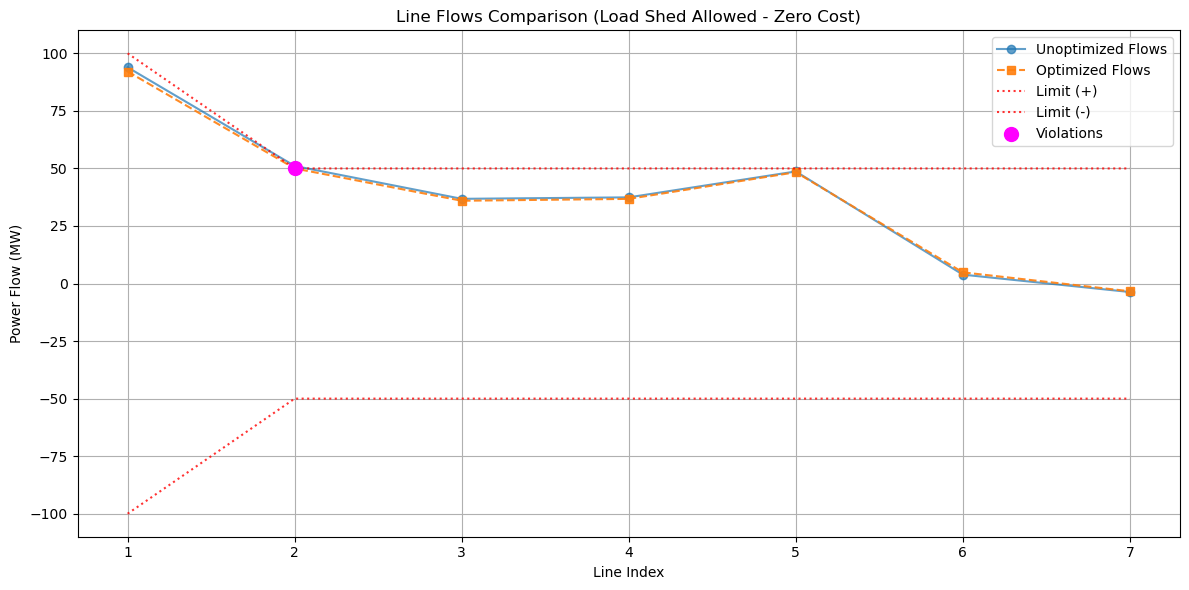

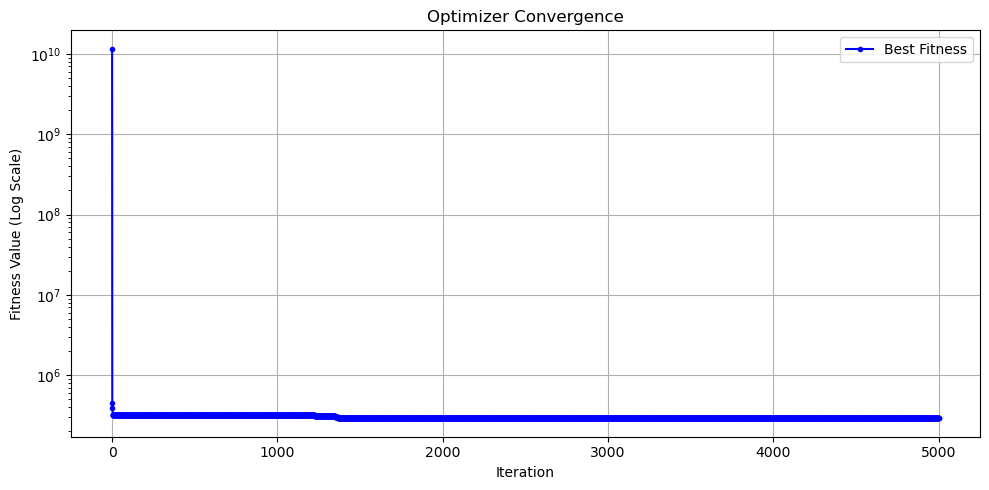

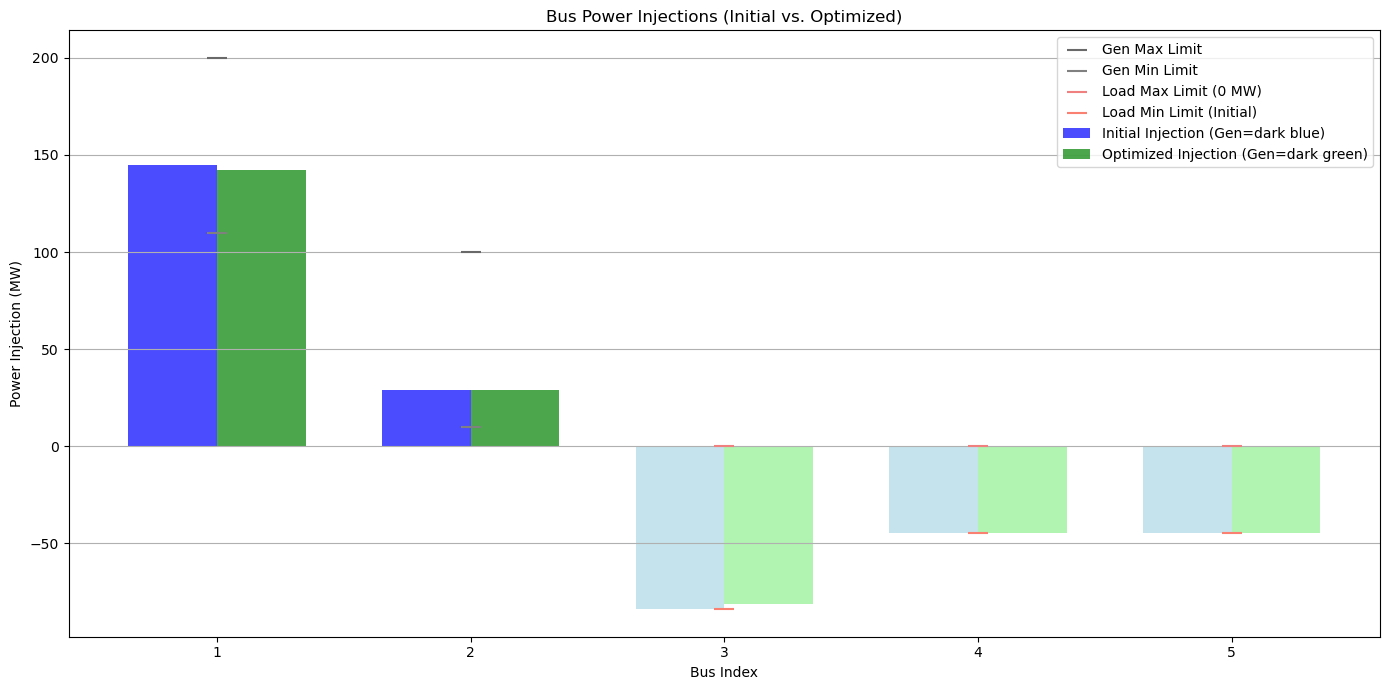

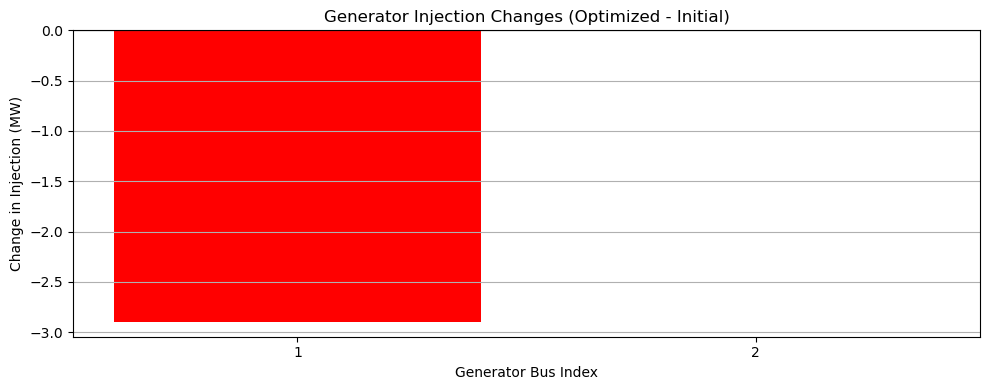

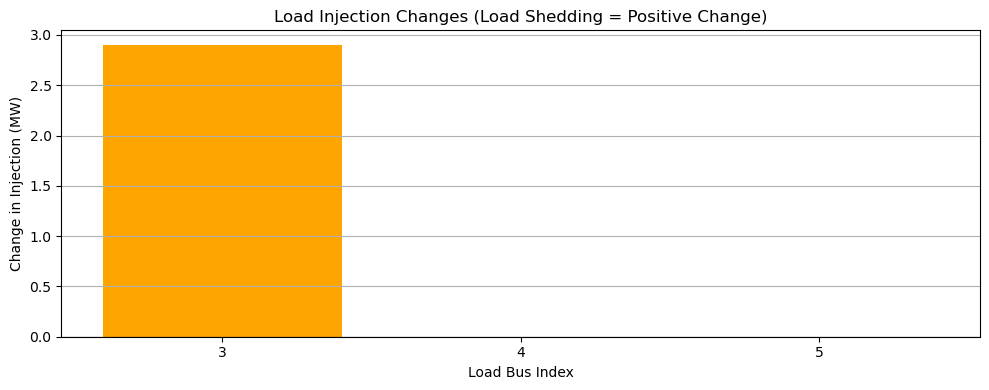


============================== RESULTS SUMMARY (Load Shed Allowed - Zero Cost) ==============================

Initial B:
[145.  29. -84. -45. -45.]

Optimized B:
[142.1  29.  -81.1 -45.  -45. ]
Sum Optimized B: 0.000000 (Should be close to 0)

Initial Flows:
[93.92 51.08 36.8  37.44 48.69  3.86 -3.69]

Optimized Flows:
[92.1  50.   35.97 36.77 48.36  4.86 -3.36]
----------------------------------------------------------------------

Objective Metrics & Load Shed:
  Generator Deviation (Sum |ΔPgen|): 2.9010 MW
  Generator Rescheduling Cost:       24.19 Crore Rs./hr
  Total Load Shed:                   2.90 MW

Constraint Check Summary (Re-Check):
--- Initializing HybridPowerFlowOptimizer ---
Identified 2 generator buses (indices: [0 1])
Identified 3 load buses (indices: [2 3 4])
Load shedding enabled: Loads can be reduced down to 0 MW (Zero Cost).
Validating and adjusting initial state...
Initial state is within limits and balanced.
Memory initialized with size 100.
--- Initialization


Run another scenario? (y/n): y



Restarting for new scenario...


========================= New Scenario (Load Shed Allowed - Zero Cost) =========================
Objective: 1. Meet Limits & Min Gen Deviation, 2. Min Gen Cost

>>> Enter LINE power limits (7 values, will use absolute value):


  Line 1 limit:  


Invalid input. Please enter numerical values only.

========================= New Scenario (Load Shed Allowed - Zero Cost) =========================
Objective: 1. Meet Limits & Min Gen Deviation, 2. Min Gen Cost

>>> Enter LINE power limits (7 values, will use absolute value):


...

  Enter Gen MIN Limit (MW):


    G1 min:  110
    G2 min:  10


  Enter Gen MAX Limit (MW):


    G1 max:  200
    G2 max:  100



========================= Running Optimization (Load Shed Allowed - Zero Cost) =========================
--- Initializing Optimizer (Load Shedding Enabled - Zero Cost) ---
--- Initializing HybridPowerFlowOptimizer ---
Identified 2 generator buses (indices: [0 1])
Identified 3 load buses (indices: [2 3 4])
Load shedding enabled: Loads can be reduced down to 0 MW (Zero Cost).
Validating and adjusting initial state...
Initial state is within limits and balanced.
Memory initialized with size 100.
--- Initialization Complete ---

--- Checking Initial State Feasibility ---

--- Feasibility Check FAILED ---
  Line constraints FAILED. Failing line indices: [4]
    Line 4: Flow=67.0170, Limit=50.0000
  Generator limits met.
  Load limits met.
  Power balance met.
------------------------------------------
Initial state feasible (after internal adjustments): False

--- Starting Optimization (Load Shedding Enabled - Zero Cost) ---

--- Starting Optimization (5000 iterations, 100 population) ---


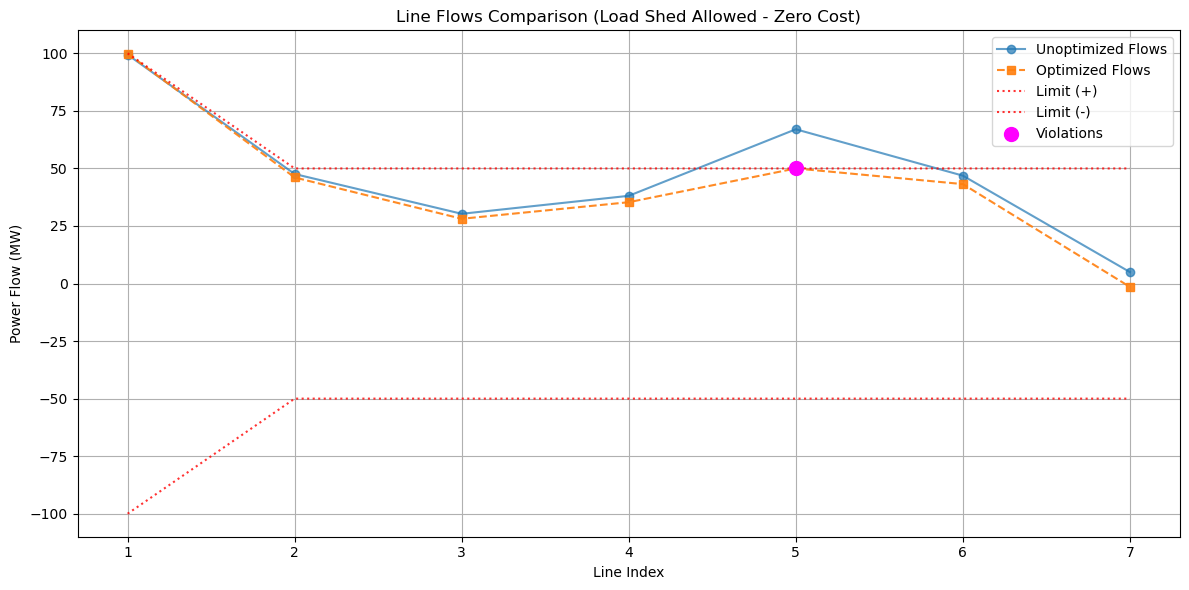

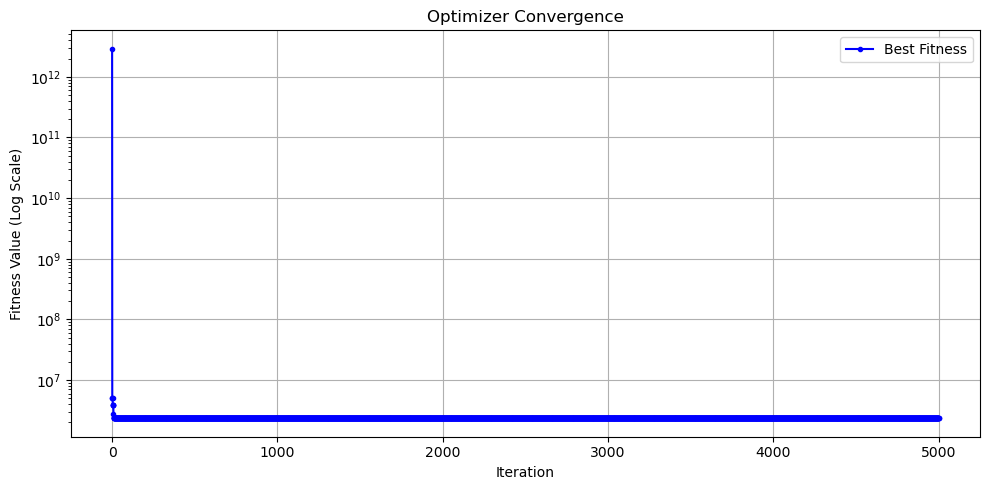

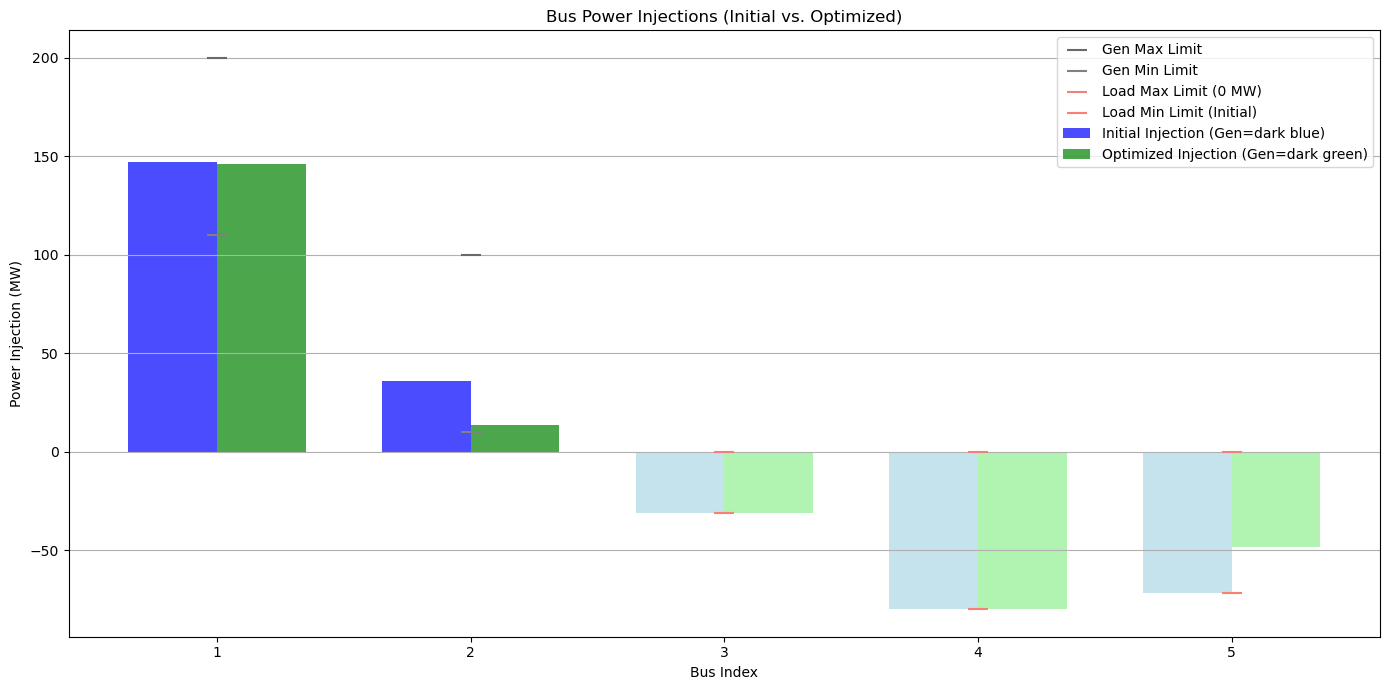

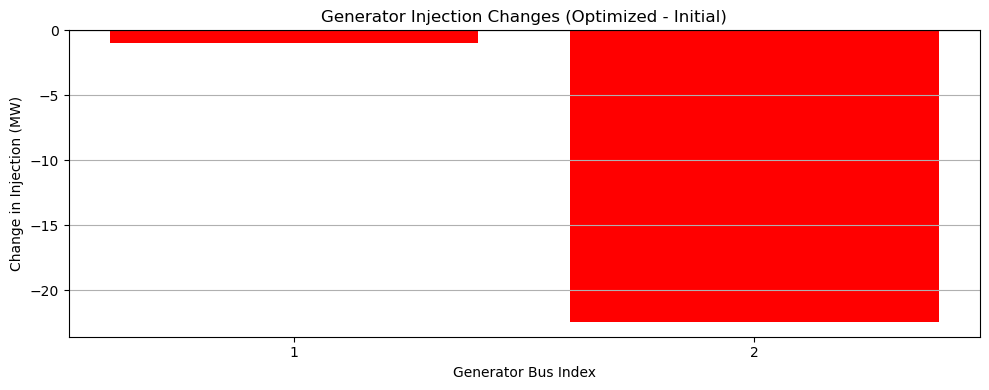

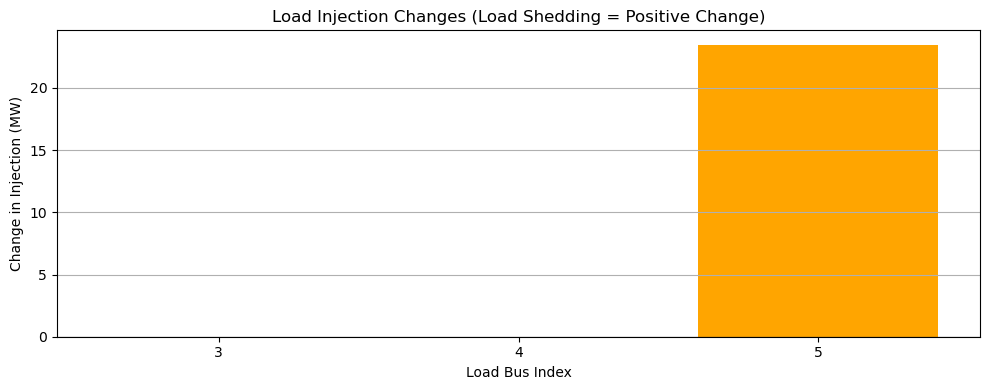


============================== RESULTS SUMMARY (Load Shed Allowed - Zero Cost) ==============================

Initial B:
[147.  36. -31. -80. -72.]

Optimized B:
[146.    13.54 -31.   -80.   -48.54]
Sum Optimized B: 0.000000 (Should be close to 0)

Initial Flows:
[99.43 47.57 30.29 38.11 67.02 46.86  4.98]

Optimized Flows:
[99.92 46.08 28.13 35.33 50.   43.2  -1.46]
----------------------------------------------------------------------

Objective Metrics & Load Shed:
  Generator Deviation (Sum |ΔPgen|): 23.4561 MW
  Generator Rescheduling Cost:       195.62 Crore Rs./hr
  Total Load Shed:                   23.46 MW

Constraint Check Summary (Re-Check):
--- Initializing HybridPowerFlowOptimizer ---
Identified 2 generator buses (indices: [0 1])
Identified 3 load buses (indices: [2 3 4])
Load shedding enabled: Loads can be reduced down to 0 MW (Zero Cost).
Validating and adjusting initial state...
Initial state is within limits and balanced.
Memory initialized with size 100.
--- Initia


Run another scenario? (y/n): N



Exiting script...


In [5]:
# Cell 5: Main execution block for running interactive scenarios

if __name__ == "__main__":

    # --- Define Fixed System Parameters ---
    # Example A matrix (e.g., Power Transfer Distribution Factor - PTDF matrix)
    # Relates bus injections to line flows (num_lines x num_buses)
    A = np.array([
        [ 0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
        [ 0.2143,  0.0571, -0.1572, -0.1143,  0.0000],
        [ 0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [ 0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [ 0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [ 0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [ 0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])
    # Get number of lines and buses from the A matrix dimensions
    num_lines_main = A.shape[0]
    num_buses_main = A.shape[1]

    # --- Main Scenario Loop ---
    # Loop indefinitely to allow running multiple scenarios without restarting the script
    while True:
        # Print header for a new scenario
        print("\n" + "="*25 + " New Scenario (Load Shed Allowed - Zero Cost) " + "="*25)
        print("Objective: 1. Meet Limits & Min Gen Deviation, 2. Min Gen Cost")

        # --- Get User Input for Scenario ---
        try:
            # Get Line Limits
            print(f"\n>>> Enter LINE power limits ({num_lines_main} values, will use absolute value):")
            # List comprehension to get input for each line, convert to float, take absolute value
            line_limits_input = np.abs(np.array([float(input(f"  Line {i+1} limit: ")) for i in range(num_lines_main)]))

            # Get Initial Bus Injections (B)
            print(f"\n>>> Enter INITIAL power injections (B) for ALL buses ({num_buses_main} values):")
            print("    (Positive for Generators, Negative for Loads)")
            # Get input for each bus, convert to float, store in a list
            B_input_list = [float(input(f"  Bus {i+1} injection: ")) for i in range(num_buses_main)]
            # Convert list to a NumPy column vector
            B_input = np.array(B_input_list).reshape(-1, 1)

            # Temporarily identify generator/load indices based *purely* on input B
            # This is used *only* for prompting the user for generator-specific data
            # The optimizer will perform its own identification in its __init__
            tolerance_input_check = 1e-6
            temp_gen_indices = np.where(B_input.flatten() > tolerance_input_check)[0]
            temp_load_indices = np.where(B_input.flatten() <= tolerance_input_check)[0]

            # Basic check: Ensure at least one generator was identified from input B
            if len(temp_gen_indices) == 0:
                print("ERROR: No generators identified from initial B values (all <= 0). Cannot proceed.")
                continue # Skip to the next iteration of the while loop

            print(f"-> Identified potential Gens (for input): {temp_gen_indices+1}, Loads: {temp_load_indices+1}")

            # Initialize arrays for generator-specific data (costs, limits)
            gen_costs_input = np.zeros(num_buses_main)
            gen_limits_min_input = np.zeros(num_buses_main) # Default min is 0
            gen_limits_max_input = np.zeros(num_buses_main) # Default max is 0

            # Get Generator-Specific Data (only for identified generator buses)
            print(f"\n>>> Enter GENERATOR specific data ONLY for buses {temp_gen_indices+1}:")

            # Get Generator Costs
            print("  Enter Gen Cost Coefficients (Crore Rs./MWh change):")
            # Loop only through the identified generator indices
            for i in temp_gen_indices:
                gen_costs_input[i] = float(input(f"    G{i+1} cost: "))

            # Get Generator Minimum Limits
            print("  Enter Gen MIN Limit (MW):")
            for i in temp_gen_indices:
                gen_limits_min_input[i] = float(input(f"    G{i+1} min: "))

            # Get Generator Maximum Limits
            print("  Enter Gen MAX Limit (MW):")
            for i in temp_gen_indices:
                gen_limits_max_input[i] = float(input(f"    G{i+1} max: "))

            # Basic check: Ensure max limit is not less than min limit for any generator
            if np.any(gen_limits_max_input[temp_gen_indices] < gen_limits_min_input[temp_gen_indices]):
                print("ERROR: Generator Max limit cannot be less than Min limit.")
                continue # Skip to the next iteration

        except ValueError:
            # Handle cases where user enters non-numeric input
            print("Invalid input. Please enter numerical values only.")
            continue # Skip to the next iteration

        # --- Run the Optimization ---
        print("\n" + "="*25 + " Running Optimization (Load Shed Allowed - Zero Cost) " + "="*25)
        # Call the wrapper function defined in Cell 3
        B_optimized, fitness_history, C_optimized, C_unoptimized, final_feasible, opt_details = optimize_power_flow_free_loadshed(
            A, B_input, line_limits_input, gen_costs_input, gen_limits_min_input, gen_limits_max_input,
            iterations=5000,      # Set number of iterations for the optimizer
            population_size=100   # Set population size for the optimizer
        )

        print("\n" + "="*25 + " Optimization Finished " + "="*25)

        # --- Visualize Results ---
        # Extract generator/load indices identified *by the optimizer* (returned in opt_details)
        # Use .get() with a default empty array in case the keys are missing
        viz_gen_indices = opt_details.get("gen_indices", np.array([]))
        viz_load_indices = opt_details.get("load_indices", np.array([]))

        print("\nVisualizing results...")
        # Call the visualization function defined in Cell 4
        visualize_results(A, B_input, B_optimized, C_optimized, C_unoptimized, line_limits_input,
                          gen_costs_input, gen_limits_min_input, gen_limits_max_input,
                          viz_gen_indices, viz_load_indices, # Pass indices from optimizer
                          fitness_history)

        # --- Save Results (Optional) ---
        # Ask user only if the final solution was deemed feasible by the optimizer wrapper
        if final_feasible:
            save = input("\nSave detailed results to file? (y/n): ").strip().lower()
            if save == 'y':
                # Get filename from user, provide a default
                fname = input("Enter filename (default: power_flow_free_loadshed_results.txt): ").strip() or "power_flow_free_loadshed_results.txt"
                try:
                    # Open the file in write mode
                    with open(fname, 'w') as f:
                        # --- Write Header ---
                        f.write("Power Flow Optimization Results (Load Shed Allowed - Zero Cost)\n")
                        f.write("Objective: 1. Meet Limits & Min Deviation, 2. Min Gen Cost\n")
                        f.write("="*30 + "\n\n")

                        # --- Write Input Parameters ---
                        f.write(f"Matrix A ({A.shape[0]}x{A.shape[1]}):\n")
                        np.savetxt(f, A, fmt='%.4f') # Save A matrix formatted
                        f.write("\n")

                        f.write("Line Limits:\n")
                        # Use list comprehension for concise writing of limits
                        [f.write(f"L{i+1}: {l:.2f}\n") for i, l in enumerate(line_limits_input)]
                        f.write("\n")

                        # Recalculate gen costs only for identified generators for saving
                        gen_costs_only_save = gen_costs_input[viz_gen_indices]
                        f.write("Gen Costs (Crore Rs./MWh change):\n")
                        [f.write(f"G{viz_gen_indices[i]+1}: {c:.2f}\n") for i, c in enumerate(gen_costs_only_save)]
                        f.write("\n")

                        f.write("Gen Min Limits (MW):\n")
                        [f.write(f"G{idx+1}: {gen_limits_min_input[idx]:.2f}\n") for idx in viz_gen_indices]
                        f.write("\n")

                        f.write("Gen Max Limits (MW):\n")
                        [f.write(f"G{idx+1}: {gen_limits_max_input[idx]:.2f}\n") for idx in viz_gen_indices]
                        f.write("\n")

                        # --- Write Initial and Optimized States ---
                        f.write("Initial B (Injections MW):\n")
                        [f.write(f"Bus {i+1}: {b[0]:.2f}\n") for i, b in enumerate(B_input)]
                        f.write("\n")

                        f.write("Optimized B (Injections MW):\n")
                        [f.write(f"Bus {i+1}: {b[0]:.2f}\n") for i, b in enumerate(B_optimized)]
                        f.write("\n")

                        f.write("Initial C (Flows MW):\n")
                        [f.write(f"L{i+1}: {c[0]:.2f}\n") for i, c in enumerate(C_unoptimized)]
                        f.write("\n")

                        f.write("Optimized C (Flows MW):\n")
                        [f.write(f"L{i+1}: {c[0]:.2f}\n") for i, c in enumerate(C_optimized)]
                        f.write("\n")

                        # --- Write Summary Metrics ---
                        # Recalculate metrics for saving (could also pass these from visualize_results)
                        final_gen_cost = np.sum(gen_costs_only_save * np.abs(B_optimized.flatten()[viz_gen_indices] - B_input.flatten()[viz_gen_indices]))
                        final_deviation_gens = np.sum(np.abs(B_optimized.flatten()[viz_gen_indices] - B_input.flatten()[viz_gen_indices]))
                        load_shed_amount = np.maximum(0, B_optimized.flatten()[viz_load_indices] - B_input.flatten()[viz_load_indices])
                        total_load_shed = np.sum(load_shed_amount)

                        f.write(f"Final Gen Deviation (Sum |ΔPgen|): {final_deviation_gens:.4f} MW\n")
                        f.write(f"Final Gen Rescheduling Cost: {final_gen_cost:.2f} $/hr\n")
                        f.write(f"Total Load Shed: {total_load_shed:.2f} MW\n")
                        f.write("\n")

                        f.write(f"Feasible: {'YES' if final_feasible else 'NO'}\n") # Use feasibility flag from optimizer

                    print(f"Results saved successfully to {fname}")
                except IOError as e:
                    # Handle potential file writing errors
                    print(f"Error saving results to file: {e}")
        elif not final_feasible:
            # Inform user if the solution was infeasible (and thus not saved)
            print("\nFinal solution was infeasible. Results not saved.")

        # --- Loop Control ---
        # Ask user if they want to run another scenario
        if input("\nRun another scenario? (y/n):").strip().lower() != 'y':
            print("\nExiting script...")
            break # Exit the while loop
        else:
            print("\nRestarting for new scenario...\n")
            # continue 



